# Transfer Learning avec TensorFlow : Guide Pédagogique

Le Transfer Learning consiste à utiliser les connaissances acquises par un modèle sur une tâche (souvent sur des millions d'images) pour les appliquer à une nouvelle tâche spécifique.

### Étapes clés :
1. **Modèle de base** : Charger un modèle pré-entraîné.
2. **Gel (Freezing)** : Bloquer les poids du modèle de base pour ne pas détruire les filtres appris.
3. **Nouvelle tête** : Ajouter des couches spécifiques à notre problème.
4. **Entraînement** : Entraîner uniquement les nouvelles couches.

In [10]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import pathlib
import os

# Paramètres
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

# Téléchargement et extraction
_URL = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
path_to_zip = tf.keras.utils.get_file('flower_photos.tgz', origin=_URL, extract=True)

# Localisation robuste du dossier flower_photos
base_path = pathlib.Path(path_to_zip).parent
data_dir = base_path / 'flower_photos'

# Si le chemin direct échoue, on cherche dans le dossier parent
if not data_dir.exists():
    data_dir = base_path / 'flower_photos_extracted' / 'flower_photos'

print(f"Chemin utilisé : {data_dir}")

# Création des datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset='training',
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset='validation',
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

# Sauvegarde des classes
class_names = train_ds.class_names
print(f"Classes trouvées : {class_names}")

# Optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Chemin utilisé : /root/.keras/datasets/flower_photos_extracted/flower_photos
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes trouvées : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Visualisation des données

Avant de passer au modèle, regardons à quoi ressemblent nos données. Voici quelques échantillons d'images du dataset de fleurs :

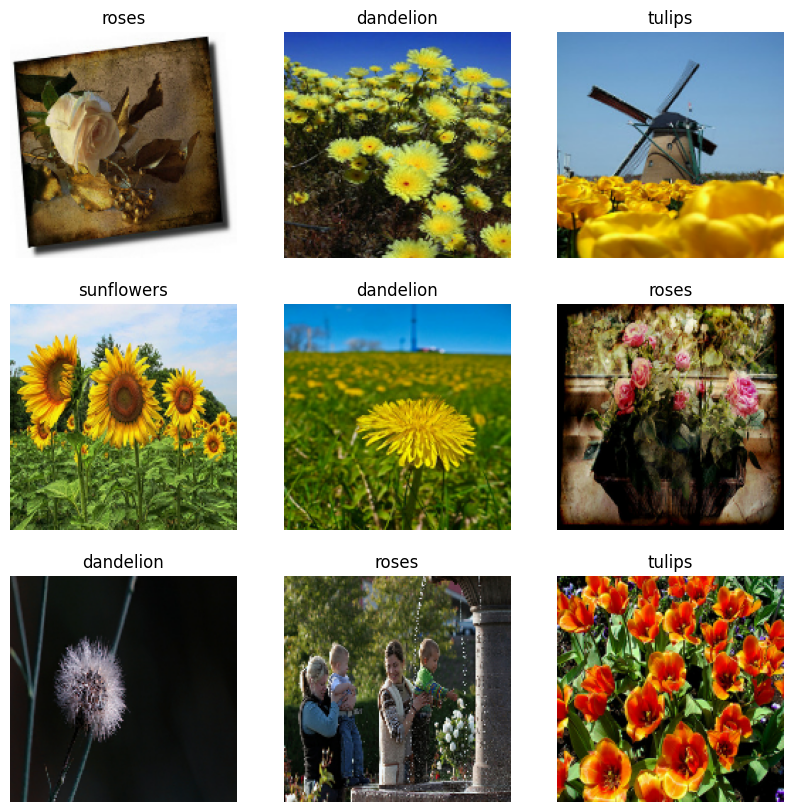

In [11]:
plt.figure(figsize=(10, 10))
# On utilise la variable class_names définie précédemment
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

## 1. Création du modèle avec poids gélés

Nous utilisons **MobileNetV2** comme base. Nous spécifions `include_top=False` pour retirer la couche de classification finale originale (conçue pour 1000 classes ImageNet).

In [12]:
# Création du modèle de base
base_model = applications.MobileNetV2(
    input_shape=(160, 160, 3), include_top=False, weights='imagenet'
  )

# IMPORTANT : On gèle les poids
base_model.trainable = False

# Architecture finale
model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1, input_shape=(160, 160, 3)), # Normalisation
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(5) # 5 types de fleurs
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2. État avant Transfer Learning

Voyons comment le modèle se comporte avec sa nouvelle tête de classification non entraînée (poids aléatoires).

In [13]:
loss0, accuracy0 = model.evaluate(val_ds)
print(f"Précision initiale : {accuracy0:.2f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 546ms/step - accuracy: 0.1894 - loss: 2.0882
Précision initiale : 0.19


## 3. Entraînement

On n'entraîne que les derniers neurones que nous avons ajoutés. Le modèle de base reste fixe.

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 184ms/step - accuracy: 0.7136 - loss: 0.7781 - val_accuracy: 0.8610 - val_loss: 0.4390
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.8804 - loss: 0.3556 - val_accuracy: 0.8815 - val_loss: 0.3681
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9063 - loss: 0.2756 - val_accuracy: 0.8801 - val_loss: 0.3323
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9315 - loss: 0.2199 - val_accuracy: 0.8842 - val_loss: 0.3179
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9479 - loss: 0.1809 - val_accuracy: 0.8883 - val_loss: 0.3098


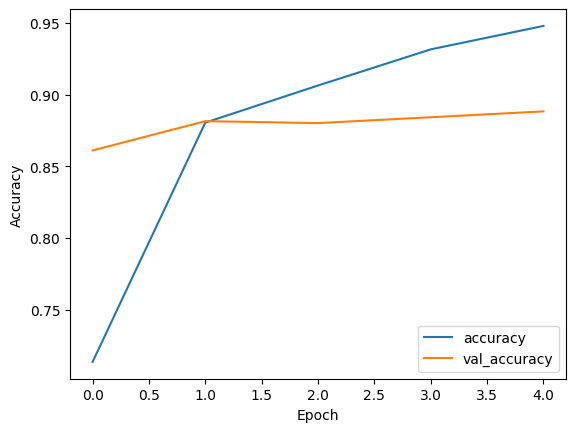

In [14]:
history = model.fit(train_ds, epochs=5, validation_data=val_ds)

# Visualisation des résultats
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

### Visualisation des prédictions

Maintenant que le modèle est entraîné (ou en cours), visualisons comment il prédit les classes sur les images de validation.

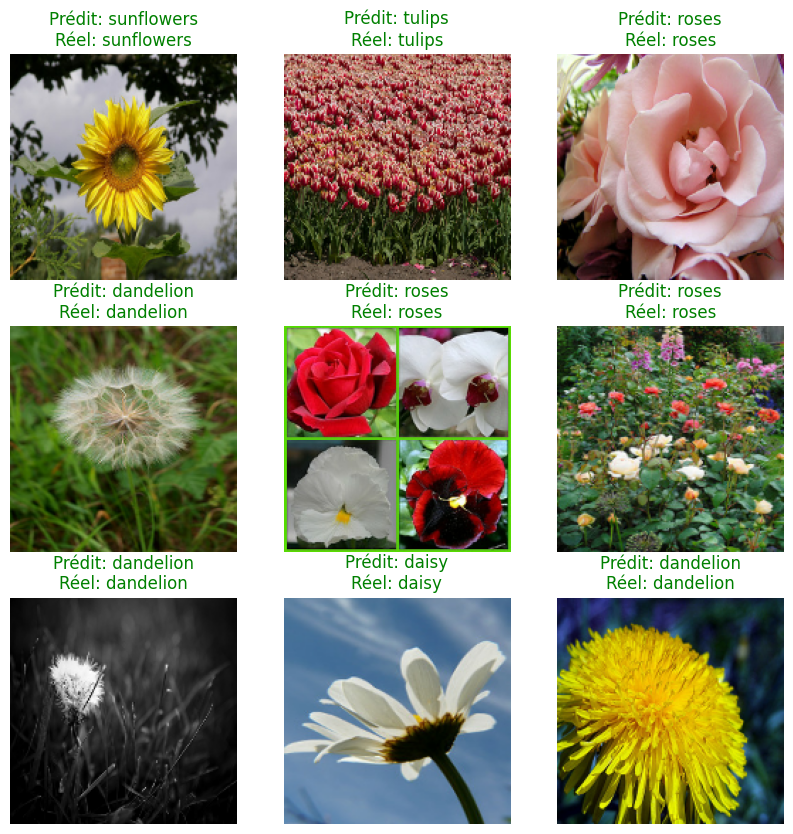

In [15]:
# Récupérer un batch d'images de validation
image_batch, label_batch = val_ds.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch)

# Appliquer softmax pour obtenir les probabilités si nécessaire, ou argmax pour la classe
predictions = tf.nn.softmax(predictions)
predicted_ids = tf.argmax(predictions, axis=-1)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].astype("uint8"))
    color = "green" if predicted_ids[i] == label_batch[i] else "red"
    plt.title(f"Prédit: {class_names[predicted_ids[i]]}\nRéel: {class_names[label_batch[i]]}", color=color)
    plt.axis("off")
plt.show()

## 4. Résultat final

Après seulement quelques époques, la précision devrait avoir bondi de manière spectaculaire par rapport à l'état initial, prouvant l'efficacité du transfert de connaissances.